In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/distance_travelled.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/distance_travelled.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/distance_travelled.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/distance_travelled.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/distance_travelled.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)


      comparison    U        p significance
anosmic vs wiii8 16.0 0.011330            *
   9047 vs wiii8  6.0 0.001008           **
  23129 vs wiii8 12.0 0.004586           **
  33300 vs wiii8  0.0 0.000183          ***


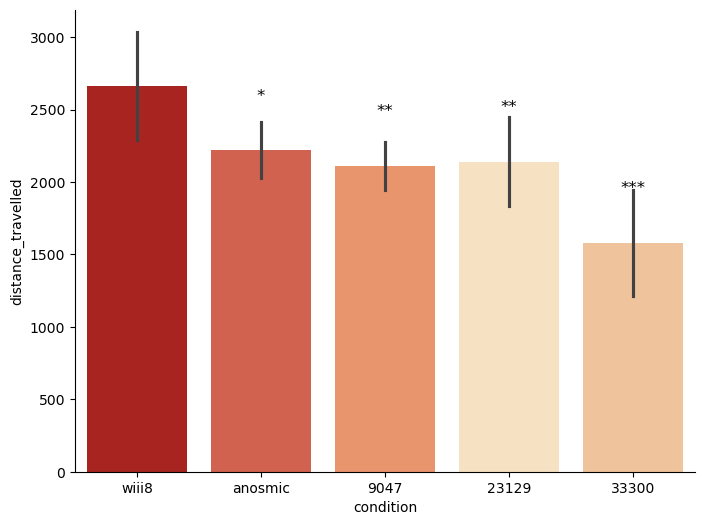

In [2]:
from scipy.stats import mannwhitneyu

distance_per_track = df.groupby(['condition', 'file', 'track'], as_index=False)['distance_travelled'].max()

distance_grouped = (
    distance_per_track.groupby(['condition', 'file'])['distance_travelled']
    .mean()
    .reset_index()
)

condition_order = ['wiii8', 'anosmic', '9047', '23129', '33300']
condition_colors = {
    'wiii8': '#be0f0a',
    'anosmic': '#e7533a',
    '9047': '#fc8c59',
    '23129': '#fee2bb',
    '33300': '#fdc38d',
}

control = distance_grouped.loc[distance_grouped['condition'] == 'wiii8', 'distance_travelled']
stats_rows = []

for condition in condition_order:
    if condition == 'wiii8':
        continue

    test_group = distance_grouped.loc[distance_grouped['condition'] == condition, 'distance_travelled']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=distance_grouped,
    x='condition',
    y='distance_travelled',
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    errorbar='sd',
    palette=condition_colors,
    legend=False,
)

y_offset = distance_grouped['distance_travelled'].max() * 0.1
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = condition_order.index(condition)
    y = distance_grouped.loc[distance_grouped['condition'] == condition, 'distance_travelled'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

sns.despine()
plt.show()
